# Scale-resolved network spectral entropy (Nicolini & Bifone, 2020)

Prototype of the **von Neumann / network spectral entropy** method of
Nicolini, Forcellini, Minati & Bifone (2020, *NeuroImage* 211:116603), built on the
network density-matrix formalism of De Domenico & Biamonte (2016), applied to the
**72×72 cosine-similarity graphs** of the afferent and efferent hippocampal connectivity
profiles.

**This is a different "spectral entropy" from `effective_dimensionality.ipynb`.** There we
took the Shannon entropy of the *covariance* eigenvalues (effective dimensionality of a
feature cloud, one number). Here we take the von Neumann entropy of the *graph Laplacian*,
swept over a **scale parameter β** — a whole curve that resolves how the network's structure
coarse-grains across scales. It is a measure of **multiscale / hierarchical organization**,
complementary to (not the same as) effective dimensionality.

## Method

Build a weighted graph from the connectivity profiles (here the 72×72 cosine-similarity
matrix `W`, non-negative, no self-loops). Then:

1. **Combinatorial Laplacian:** $L = D - W$, with $D = \mathrm{diag}(\sum_j W_{ij})$.
   Eigenvalues $0 = \lambda_1 \le \lambda_2 \le \dots \le \lambda_N$.
2. **Network density matrix** (a Gibbs state; $e^{-\beta L}$ is the heat-diffusion kernel, so
   $\beta$ acts like diffusion time / inverse temperature — a **scale**):
   $$\rho(\beta) = \frac{e^{-\beta L}}{Z(\beta)}, \qquad Z(\beta) = \mathrm{Tr}\,e^{-\beta L} = \sum_i e^{-\beta \lambda_i}.$$
3. **Spectral (von Neumann) entropy:**
   $$S(\beta) = -\mathrm{Tr}(\rho \ln \rho) = -\sum_i \mu_i \ln \mu_i, \qquad \mu_i = \frac{e^{-\beta \lambda_i}}{Z(\beta)}.$$
4. **Scale behaviour:** $\beta \to 0 \Rightarrow S \to \ln N$ (all modes equal, network looks
   like $N$ separate units); $\beta \to \infty \Rightarrow S \to \ln(\#\text{components}) = 0$
   for a connected graph. Intermediate $\beta$ exposes mesoscale/community structure.
5. **Characteristic scales** are read off the **specific heat** $C(\beta) = -\,dS/d\ln\beta$:
   its peaks mark the scales at which structure reorganizes (e.g. communities merging). The
   $S(\beta)$ curves themselves serve as network "fingerprints" for comparing conditions —
   here, afferent vs efferent. A selling point of the method is that it works on the full
   weighted graph, with **no arbitrary thresholding**.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks

from helpers import get_feature_vectors_shared_hpc, log_weight_transform

# Afferent (partner -> HPC) and efferent (HPC -> partner) fingerprints:
# 72 partner regions (nodes) x 7 hippocampal subfields (features).
df_to, df_from = get_feature_vectors_shared_hpc()
X_aff = log_weight_transform(df_to.values).T
X_eff = log_weight_transform(df_from.values).T


def cosine_graph(X):
    # 72x72 cosine-similarity graph of the partners' 7-D fingerprints.
    # Non-negative weights (cosine of non-negative vectors), no self-loops.
    W = np.clip(cosine_similarity(X), 0.0, 1.0)
    np.fill_diagonal(W, 0.0)
    return W


W_aff, W_eff = cosine_graph(X_aff), cosine_graph(X_eff)
print('afferent graph:', W_aff.shape, '| efferent graph:', W_eff.shape,
      '| both fully weighted (no thresholding)')

afferent graph: (72, 72) | efferent graph: (72, 72) | both fully weighted (no thresholding)


In [2]:
def laplacian_spectrum(W):
    # Combinatorial graph Laplacian L = D - W; return its non-negative eigenvalues (ascending).
    L = np.diag(W.sum(axis=1)) - W
    return np.clip(np.linalg.eigvalsh(L), 0.0, None)


def spectral_entropy(lam, betas):
    # von Neumann entropy S(beta) of rho(beta) = exp(-beta L)/Z for each beta.
    # mu_i = exp(-beta lam_i)/Z ; S = -sum mu_i ln mu_i  (nats). Uses stable log-sum-exp.
    S = np.empty(len(betas))
    for k, b in enumerate(betas):
        e = -b * lam
        log_mu = e - np.logaddexp.reduce(e)          # normalize: subtract ln Z
        S[k] = -np.sum(np.exp(log_mu) * log_mu)
    return S


betas = np.logspace(-3, 2, 400)                       # scale sweep (log-spaced)
lam_aff, lam_eff = laplacian_spectrum(W_aff), laplacian_spectrum(W_eff)
S_aff, S_eff = spectral_entropy(lam_aff, betas), spectral_entropy(lam_eff, betas)

# Specific heat C(beta) = -dS/d(ln beta); its peaks are the characteristic scales.
C_aff = -np.gradient(S_aff, np.log(betas))
C_eff = -np.gradient(S_eff, np.log(betas))

N = W_aff.shape[0]
print(f'ln N = {np.log(N):.3f}  (S at beta->0);   S at beta->inf -> 0 (connected graph)\n')
for name, lam, C in [('afferent', lam_aff, C_aff), ('efferent', lam_eff, C_eff)]:
    pk, _ = find_peaks(C)
    print(f'{name}: algebraic connectivity lambda_2 = {lam[1]:.3f} | '
          f'specific-heat peaks at beta = {np.round(betas[pk], 3)}  ({len(pk)} characteristic scale(s))')

ln N = 4.277  (S at beta->0);   S at beta->inf -> 0 (connected graph)

afferent: algebraic connectivity lambda_2 = 4.691 | specific-heat peaks at beta = [0.393]  (1 characteristic scale(s))
efferent: algebraic connectivity lambda_2 = 1.871 | specific-heat peaks at beta = [0.131]  (1 characteristic scale(s))


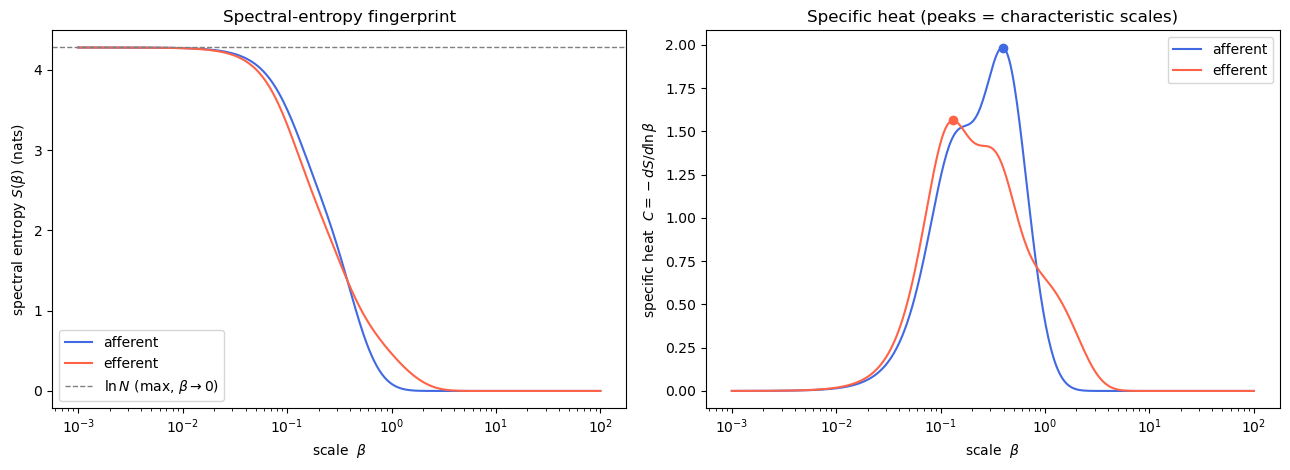

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# S(beta): the spectral-entropy fingerprint of each network.
axes[0].plot(betas, S_aff, color='royalblue', label='afferent')
axes[0].plot(betas, S_eff, color='tomato', label='efferent')
axes[0].axhline(np.log(N), color='gray', ls='--', lw=1, label=r'$\ln N$ (max, $\beta\to0$)')
axes[0].set_xscale('log'); axes[0].set_xlabel(r'scale  $\beta$')
axes[0].set_ylabel(r'spectral entropy $S(\beta)$ (nats)')
axes[0].set_title('Spectral-entropy fingerprint'); axes[0].legend()

# Specific heat: peaks = characteristic scales / structural transitions.
for S, C, color, name in [(S_aff, C_aff, 'royalblue', 'afferent'),
                          (S_eff, C_eff, 'tomato', 'efferent')]:
    axes[1].plot(betas, C, color=color, label=name)
    pk, _ = find_peaks(C)
    axes[1].plot(betas[pk], C[pk], 'o', color=color)
axes[1].set_xscale('log'); axes[1].set_xlabel(r'scale  $\beta$')
axes[1].set_ylabel(r'specific heat  $C=-dS/d\ln\beta$')
axes[1].set_title('Specific heat (peaks = characteristic scales)'); axes[1].legend()

plt.tight_layout(); plt.show()

## Reading the comparison

Both networks start at $S = \ln N$ (β→0, everything separate) and decay to $0$ (β→∞, one
connected blob), but the **shape between those limits differs** — that shape is the
scale-resolved fingerprint:

- The **specific-heat peaks** locate each network's characteristic scale(s). Afferent and
  efferent peak at **different β**, i.e. their connectivity reorganizes at different scales —
  a structural difference the single-number effective dimensionality can't express.
- $\lambda_2$ (algebraic connectivity) differs between directions; a smaller $\lambda_2$ means
  slower diffusion / more separated structure, shifting the transition to smaller β.

How to place this alongside the rest of the project:

- **vs. effective dimensionality (`effective_dimensionality.ipynb`):** that gives *how many
  variance dimensions* the profiles span (one number); this gives *how the network coarse-grains
  across scales* (a curve). Complementary, not redundant.
- **vs. diffusion maps (`diffusion_map_embedding.ipynb`):** same $e^{-\beta L}$ heat kernel —
  β here is the diffusion-time knob there. This is the entropy counterpart of that embedding.
- **vs. SBM (`hippocampal_sbm.ipynb`):** the number of specific-heat peaks estimates how many
  structural scales exist, a soft cross-check on the SBM block counts.

**Caveats.** This measures multiscale *network* structure, not feature-space dimensionality; it
depends on the graph construction (here cosine similarity); and $\exp(S(\beta))$ is best read as
the *effective number of active diffusion modes at scale β*, which has a dimensionality flavour
but is a property of the Laplacian spectrum, not the covariance.